In [5]:
# Finite Differences comparison

In [1]:
include("../src/main.jl")
println("Available threads: ", nthreads())
println("RHO_unit:", RHO_unit)

Using model: iharm, change src/set_globals.jl to modify.
Available threads: 1
RHO_unit:3.906325282703709e-19


In [2]:
#dump_filepath = "../src/models/iharm3dDumps/dump_001.h5";
dump_filepath = "../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5"

#dump_filepath = "../../../../Downloads/torus.out0.00356.h5";

"../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5"

In [54]:
#TODO: put this in reading file
const N1 = 288
const N2 = 128
const N3 = 128

const METRIC = "MKS" #FMKS or MKS TODO: prob have to be read from file
trat_large = 20. #TODO: prob have to be read from file
const trat_small = 1. #TODO: prob have to be read from file
const beta_crit = 1.0 #TODO: prob have to be read from file
const game = (4. /3.)  # Ion adiabatic index  TODO: prob have to be read from file
const gamp = (5. /3.)  # Electron adiabatic index TODO: prob have to be read from file
const gam = (1.444444)  # Total adiabatic index TODO: prob have to be read from file
const Ne_factor = 1.0  # Scaling factor for electron number density TODO: prob have to be read from file
const rmin_geo = 1.00187575798832   #TODO: Has to be read from file as Rin and compared to the value chosen
const rmax_geo = 100. #TODO: Has to be read from file as Rin and compared to the value chosen
const th_beg = 1.74e-2 #TODO: Idk where this comes from, check ipole source code
const sigma_cut = 1. #TODO: maybe put it somewhere else?
const sigma_cut_high = -1.
const startx::MVec4 = [0, 1.635684465252566e-01, 0, 0]#TODO: prob have to be read from file
const stopx::MVec4 = [1,  6.907755278982137, 1, 2 * π]#TODO: prob have to be read from file
const dx::MVec4 =[0, 2.341731539047528e-02, 7.812500000000000e-03, 4.908738521234052e-02]
const bhspin = 0.9375 #TODO: prob have to be read from file
const hslope = 0.3 #TODO: prob have to be read from file


0.3

In [45]:
const simulation_data = load_data(dump_filepath, trat_large);

Loading data from '../../gpumonty/data/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (288, 128, 128)


In [46]:
#Setting up the parameters
#Observer distance in Rg
const ro = 1000.0
#Observer inclination in degrees
const th = 60.0

#Observer azimuth in degrees
const phi = 0.0

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
const pixels_x = 80
const pixels_y = 80
# Distance to the source in parsecs
const SourceD = 16.9e6 * PC #GRMHD
#const SourceD = 7.778e3 * PC #Analytical
const Rout = 1000.0
const Rstop = 100.0
const Rh = 1 + sqrt(1. - bhspin * bhspin);

#Check if these are correct
#const cstartx = MVec4(0.0, log(Rh), 0.0, 0.0)#Analytical
const cstartx = MVec4(0.0, 0.0, 0.0, 0.0)#GRMHD
const cstopx = MVec4(0.0, log(Rout), 1.0, 2.0 * π)#TODO: prob have to be read from file

# Frequency observed by the camera in Hz
const freq = 230e9;

# Size of the screen in Rg in both directions
const DXsize = SourceD/L_unit/MUAS_PER_RAD * 160 #GRMHD
#const DXsize = 30 #analytical
const DYsize = SourceD/L_unit/MUAS_PER_RAD * 160 #GRMHD
#const DYsize = 30 #analytical

# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
const fovx = DXsize/ro
const fovy = DYsize/ro
const xoff = 0.0
const yoff = 0.0
const nmaxstep = 15000
const nx, ny = pixels_x, pixels_y


(80, 80)

In [47]:
include("../src/main.jl")
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)
const nx, ny = pixels_x, pixels_y
dI_dθo_arr = Matrix{Float64}(undef, nx, ny)
dI_dRhigh_arr = Matrix{Float64}(undef, nx, ny)
I_arr = Matrix{Float64}(undef, nx, ny)

# Constants
const DX =DXsize
const DY = DYsize
const scale_factor = CalculateScaleFactor(DX, DY, nx, ny, SourceD, L_unit)

# Pre-allocate trajectory arrays for each thread
num_threads = Threads.nthreads()
thread_trajs = Vector{Vector{OfTraj}}(undef, (num_threads+1))
for tid in 1:(num_threads + 1)
    # Create default OfTraj objects with proper arguments. We allocate trajs outside.
    default_float = 0.0
    default_mvector = MVector{4, Float64}(0.0, 0.0, 0.0, 0.0)
    thread_trajs[tid] = [OfTraj(default_float, 
                                default_mvector, default_mvector, default_mvector, default_mvector,
                                default_mvector, default_mvector, default_mvector, default_mvector) 
                        for _ in 1:nmaxstep]
end

progress = zeros(Int, Threads.nthreads())
total = nx * ny
p = Progress(
    total; 
    desc = "Computing Image and Sensitivity...", 
    showspeed = true, 
    barlen = 30
)

Threads.@threads for i in 0:(nx - 1)
    tid = Threads.threadid()
    for j in 0:(ny - 1)
        dI_dθo_out = Ref{Float64}(0.0)
        intensity_out = Ref{Float64}(0.0)
        dI_dRhigh_out = Ref{Float64}(0.0)
        
        AutoDiffGeoTrajEulerMethod_GRMHD!(
            thread_trajs[tid], dI_dθo_out, intensity_out, dI_dRhigh_out,
            ro, th, phi, bhspin, nx, ny, nmaxstep, i, j, 
            freq, fovx, fovy, Rout, Rstop, simulation_data
        )
        
        dI_dRhigh_arr[i + 1, j + 1] = dI_dRhigh_out[]
        dI_dθo_arr[i + 1, j + 1] = dI_dθo_out[]
        I_arr[i + 1, j + 1] = intensity_out[]

        # Update the progress bar
        ProgressMeter.next!(
            p; 
            showvalues = [
                (:thread_id, tid), 
                (:pixel, "($i, $j)"), 
                (:total_done, "$(i*ny + j)/$total")
            ]
        )
    end
end

finish!(p)

Computing Image and Sensitivity... 100%|██████████████████████████████| Time: 0:03:00 (28.23 ms/it)
    thread_id: 1
        pixel: (79, 79)
   total_done: 6399/6400


In [48]:
dI_dth_FD, Img_FD = FiniteDifferencesθ(ro, th, phi, DXsize, DYsize, nx, ny, SourceD, freq, 15000, 1e-6, bhspin, Rout, Rstop, simulation_data)

Raytracing Central... 100%|██████████████████████████████| Time: 0:00:26 ( 4.19 ms/it)
    thread_id: 1
        pixel: (79, 79)
   total_done: 6399/6400


([-2.1057287343039823e-31 -1.0530326217592519e-30 … 2.4046571015946744e-31 2.3311862509946704e-30; 3.68574741923493e-33 -2.0032396465671028e-30 … 1.7491186125282537e-30 4.284088768367478e-31; … ; 1.2465056055697654e-38 -3.029902050466288e-38 … -5.6072116610171524e-36 -4.0294370083027814e-36; 1.0655572436950426e-39 5.879770872552603e-39 … -1.64857281451698e-36 -5.653799495106157e-37], [1.8211118842257007e-30 2.9644400527911032e-30 … 2.2247184308554718e-29 1.8191815317338378e-29; 2.232320489371441e-30 4.2825392272849015e-30 … 3.2547443247150176e-29 8.986819760371582e-30; … ; 1.5411990313456415e-38 3.6588477433094173e-38 … 2.687797522881543e-35 8.479453690012069e-36; 1.7598202253719318e-39 2.1019766956222517e-39 … 3.542685729602489e-36 8.233955633799949e-37])

NMSE: 1.21e10


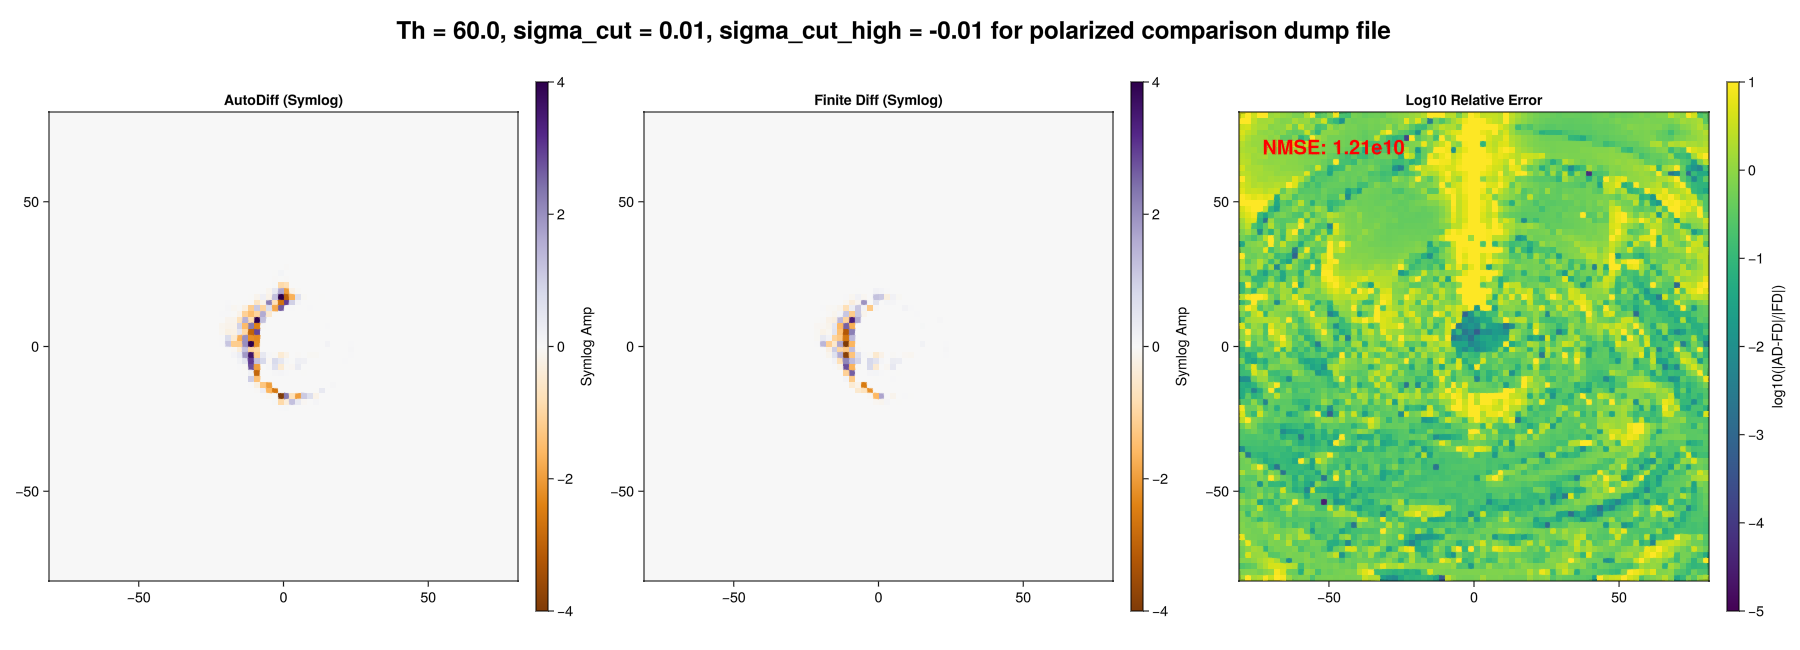

In [53]:
using GLMakie
using Statistics

# -----------------------------
# 0. Physics & Coordinates Setup
# -----------------------------
d_kpc = 16900
d_cm = d_kpc * 3.086e21
fov_rg = 44.17
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm
theta_μas = theta_rad * MUAS_PER_RAD

# Coordinates
x_coords = range(-theta_μas, theta_μas, length=nx)
y_coords = range(-theta_μas, theta_μas, length=ny)

# -----------------------------
# 1. Symlog Transformation
# -----------------------------
function symlog(x, linthresh)
    absx = abs(x)
    if absx <= linthresh
        return x / linthresh
    else
        return sign(x) * (1 + log10(absx / linthresh))
    end
end

linthresh = 1e-7
dI_AD_sym = symlog.(dI_dθo_arr, linthresh)
dI_FD_sym = symlog.(dI_dth_FD, linthresh)

# -----------------------------
# 2. Simple Relative Error
# -----------------------------
rel_err = abs.(dI_dθo_arr .- dI_dth_FD) ./ abs.(dI_dth_FD)
log_rel_err = log10.(rel_err)

# -----------------------------
# 2.5 NMSE Calculation
# -----------------------------
# mse = np.sum((img1 - img2)**2)
# reference_energy = np.sum(img2**2)
# nmse = mse / reference_energy

# Note: We filter(isfinite, ...) to ensure NaNs in the background don't ruin the sum
diff_sq = (dI_dθo_arr .- dI_dth_FD).^2
ref_sq  = dI_dth_FD.^2

mse = sum(filter(isfinite, diff_sq))
ref_energy = sum(filter(isfinite, ref_sq))
nmse = mse / ref_energy

# Prepare string for plotting
nmse_str = "NMSE: $(round(nmse, sigdigits=4))"
println(nmse_str)

# -----------------------------
# 3. Plotting
# -----------------------------
# Increased height to fit the bottom label
fig = Figure(size = (1800, 650)) 

# --- Main Title ---
Label(fig[0, 1:6], "Th = $th, sigma_cut = $sigma_cut, sigma_cut_high = $sigma_cut_high for polarized comparison dump file", 
      fontsize = 24, font = :bold)

# Shared limits
max_sym = 4.

# --- Plot 1: AutoDiff ---
ax1 = Axis(fig[1, 1], title = "AutoDiff (Symlog)", aspect = 1, backgroundcolor=:gray95)
hm1 = heatmap!(ax1, x_coords, y_coords, dI_AD_sym, 
    colormap = :PuOr, colorrange = (-max_sym, max_sym)) 
Colorbar(fig[1, 2], hm1, label = "Symlog Amp")

# --- Plot 2: Finite Diff ---
ax2 = Axis(fig[1, 3], title = "Finite Diff (Symlog)", aspect = 1, backgroundcolor=:gray95)
hm2 = heatmap!(ax2, x_coords, y_coords, dI_FD_sym, 
    colormap = :PuOr, colorrange = (-max_sym, max_sym))
Colorbar(fig[1, 4], hm2, label = "Symlog Amp")

# --- Plot 3: Relative Error ---
ax3 = Axis(fig[1, 5], title = "Log10 Relative Error", aspect = 1, backgroundcolor=:gray95)
hm3 = heatmap!(ax3, x_coords, y_coords, log_rel_err, 
    colormap = :viridis, colorrange = (-5, 1))
Colorbar(fig[1, 6], hm3, label = "log10(|AD-FD|/|FD|)")
# Print NMSE directly onto the Relative Error axis (top-left corner)
text!(ax3, 0.05, 0.95, text = nmse_str, 
      space = :relative, align = (:left, :top), 
      fontsize = 20, font = :bold, color = :red)



fig

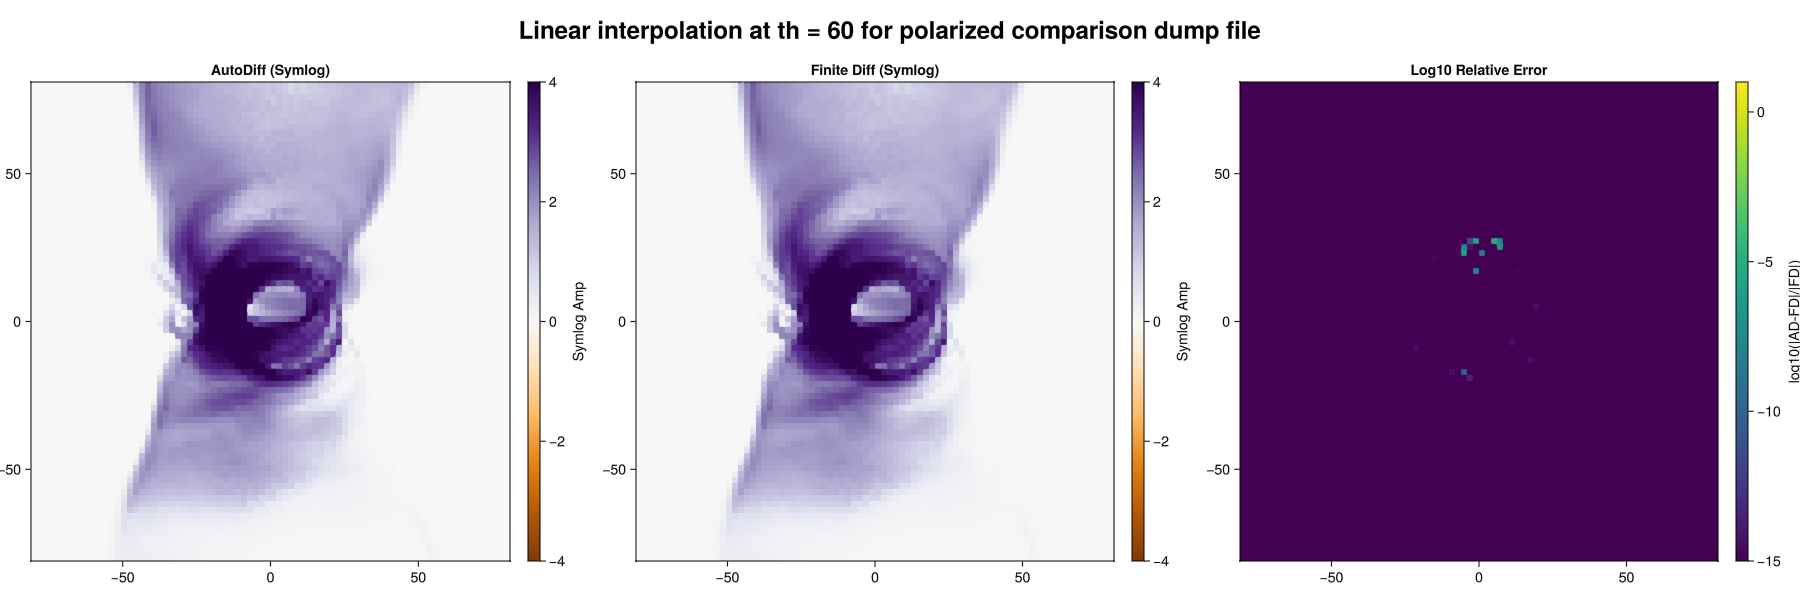

In [12]:
using GLMakie
using Statistics

# -----------------------------
# 0. Physics & Coordinates Setup
# -----------------------------
d_kpc = 16900
d_cm = d_kpc * 3.086e21
fov_rg = 44.17
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm
theta_μas = theta_rad * MUAS_PER_RAD

# Coordinates
x_coords = range(-theta_μas, theta_μas, length=nx)
y_coords = range(-theta_μas, theta_μas, length=ny)

# -----------------------------
# 1. Symlog Transformation
# -----------------------------
function symlog(x, linthresh)
    absx = abs(x)
    if absx <= linthresh
        return x / linthresh
    else
        return sign(x) * (1 + log10(absx / linthresh))
    end
end

linthresh = 1e-7 
dI_AD_sym = symlog.(I_arr, linthresh)
dI_FD_sym = symlog.(Img_FD, linthresh)

# -----------------------------
# 2. Simple Relative Error
# -----------------------------
rel_err = abs.(I_arr .- Img_FD) ./ abs.(Img_FD)
log_rel_err = log10.(rel_err)

# -----------------------------
# 3. Plotting
# -----------------------------
# Increased width to give panels room
fig = Figure(size = (1800, 600)) 

# --- Main Title ---
# Span across all 6 columns (3 plots + 3 colorbars)
Label(fig[0, 1:6], "Linear interpolation at th = 60 for polarized comparison dump file", 
      fontsize = 24, font = :bold)

# Shared limits
max_sym = 4

# --- Plot 1: AutoDiff ---
# Added backgroundcolor=:gray95 to see the plot extent clearly
ax1 = Axis(fig[1, 1], title = "AutoDiff (Symlog)", aspect = 1, backgroundcolor=:gray95)
hm1 = heatmap!(ax1, x_coords, y_coords, dI_AD_sym, 
    colormap = :PuOr, colorrange = (-max_sym, max_sym)) 
Colorbar(fig[1, 2], hm1, label = "Symlog Amp")

# --- Plot 2: Finite Diff ---
ax2 = Axis(fig[1, 3], title = "Finite Diff (Symlog)", aspect = 1, backgroundcolor=:gray95)
hm2 = heatmap!(ax2, x_coords, y_coords, dI_FD_sym, 
    colormap = :PuOr, colorrange = (-max_sym, max_sym))
Colorbar(fig[1, 4], hm2, label = "Symlog Amp")

# --- Plot 3: Relative Error ---
ax3 = Axis(fig[1, 5], title = "Log10 Relative Error", aspect = 1, backgroundcolor=:gray95)
hm3 = heatmap!(ax3, x_coords, y_coords, log_rel_err, 
    colormap = :viridis,
    colorrange = (-15, 1)) # <--- Set manually here
Colorbar(fig[1, 6], hm3, label = "log10(|AD-FD|/|FD|)")

# ---------------------------------------------------------
# LAYOUT FIX: Force columns 1, 3, and 5 to be equal squares
# ---------------------------------------------------------
for col in [1, 3, 5]
    colsize!(fig.layout, col, Aspect(1, 1.0))
end

fig